<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polynomial Regression - From Intuition to Practical Machine Learning

### 6-Month Joint Certification Programme in AI & ML
**NIELIT Ropar with IIT Ropar**

---
*Colab notebook · Run each cell top to bottom during the live session.*

## Learning Objectives

By the end of this notebook, students will be able to:

1. Explain what Polynomial Regression is.
2. Understand why Linear Regression may fail on nonlinear relationships.
3. Distinguish between Linear and Polynomial Regression.
4. Understand polynomial features such as $x^2, x^3, \ldots$
5. Understand **Simple Polynomial Regression**.
6. Understand **Multiple Polynomial Regression**.
7. Understand polynomial degree.
8. Generate polynomial features using `PolynomialFeatures`.
9. Train a Polynomial Regression model using `LinearRegression`.
10. Visualize polynomial regression curves.
11. Understand underfitting and overfitting.
12. Compare different polynomial degrees.
13. Evaluate models using MAE, MSE, RMSE and $R^2$.
14. Understand why feature scaling can become important with high-degree polynomial features.
15. Build an end-to-end Polynomial Regression project.

## 🔧 Setup

Run this cell first — it imports every library used in the notebook and sets a consistent plotting style.

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
print("Libraries imported successfully...")

Libraries imported successfully...


## 1️⃣ Introduction

**Regression** is a supervised learning technique used to predict a continuous numeric value (e.g. price, temperature, salary) from one or more input features.

**Linear Regression** models the relationship between input(s) and output as a *straight line* (or a flat plane in higher dimensions).

**Polynomial Regression** extends this idea by allowing the relationship to be a *curve*, so it can capture bends and turns in the data that a straight line cannot.

### Why do we need Polynomial Regression?

Many real-world relationships are **not** straight lines:

- Growth of a plant over time (fast, then slows down)
- Speed vs. fuel efficiency of a car (efficiency drops at very low and very high speeds)
- Price of a house vs. its age (value drops, then may rise again for "vintage" properties)
- Distance travelled by a falling object over time (follows $t^2$)

When the true relationship curves, forcing a straight line onto it produces a poor fit — no matter how much data you add.

| Model                  | Relationship   | Equation shape                                   |
|-------------------------|----------------|---------------------------------------------------|
| Linear Regression        | Straight line  | $\hat{y} = \beta_0 + \beta_1x$                    |
| Polynomial Regression    | Curve          | $\hat{y} = \beta_0 + \beta_1x + \beta_2x^2 + \cdots$ |

## 2️⃣ Linear Regression Recap

Before jumping into Polynomial Regression, let's quickly revise **Simple Linear Regression**.

$$\hat{y} = \beta_0 + \beta_1x$$

Where:

- $x$ → the input feature
- $y$ → the true target value
- $\hat{y}$ → the predicted value
- $\beta_0$ → intercept (value of $y$ when $x = 0$)
- $\beta_1$ → slope (how much $y$ changes per unit change in $x$)

Let's create a small synthetic dataset that genuinely follows a straight-line pattern and fit a Linear Regression model to it.

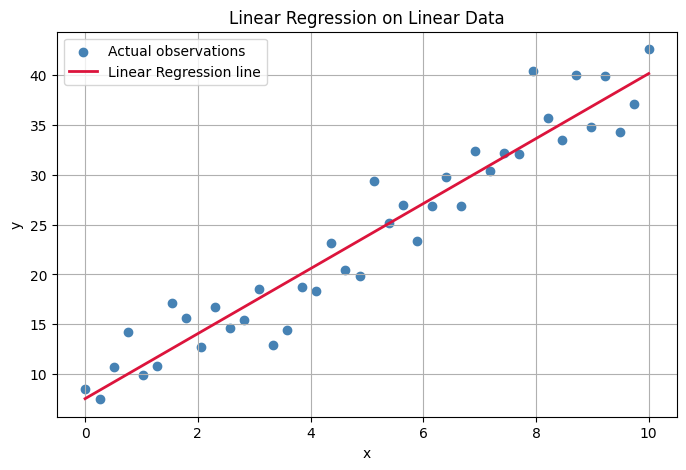

Learned equation: y = 7.54 + 3.26 * x


In [88]:
# Small synthetic dataset with a linear relationship
X_lin = np.linspace(0, 10, 40).reshape(-1, 1)
y_lin = 3.5 * X_lin.ravel() + 7 + np.random.normal(0, 3, size=X_lin.shape[0])

lin_model = LinearRegression()
lin_model.fit(X_lin, y_lin)
y_lin_pred = lin_model.predict(X_lin)

plt.scatter(X_lin, y_lin, label="Actual observations", color="steelblue")
plt.plot(X_lin, y_lin_pred, label="Linear Regression line", color="crimson", linewidth=2)
plt.title("Linear Regression on Linear Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

print(f"Learned equation: y = {lin_model.intercept_:.2f} + {lin_model.coef_[0]:.2f} * x")

## 3️⃣ Why Linear Regression Can Fail

Now let's generate data from a **nonlinear** (quadratic) relationship:

$$y = 2x^2 + 3x + 5 + \text{noise}$$

and see what happens when we fit a straight line to it.

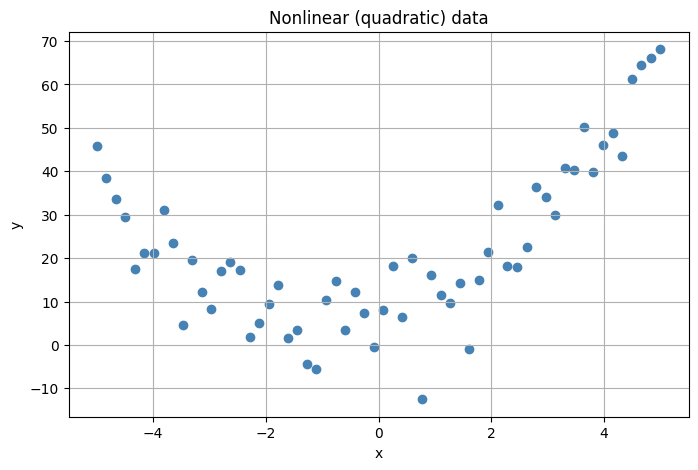

In [89]:
# Synthetic nonlinear (quadratic) dataset
X_nl = np.linspace(-5, 5, 60).reshape(-1, 1)
y_nl = 2 * X_nl.ravel()**2 + 3 * X_nl.ravel() + 5 + np.random.normal(0, 8, size=X_nl.shape[0])

plt.scatter(X_nl, y_nl, color="steelblue")
plt.title("Nonlinear (quadratic) data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

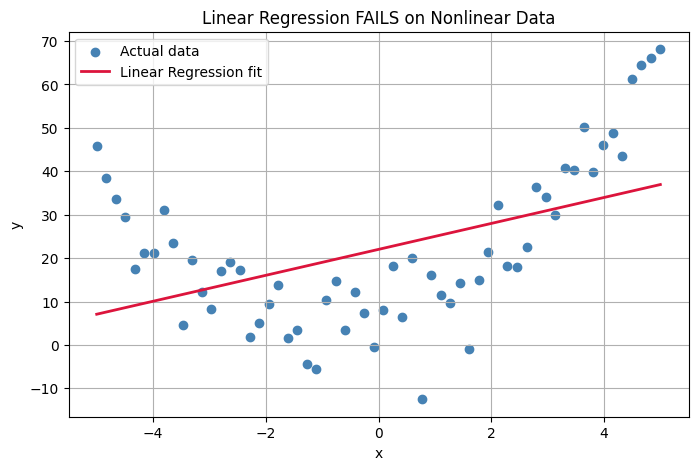

R² of straight-line fit on curved data: 0.226


In [90]:
# Fit a plain Linear Regression on the nonlinear data
lin_on_nl = LinearRegression()
lin_on_nl.fit(X_nl, y_nl)
y_nl_pred = lin_on_nl.predict(X_nl)

plt.scatter(X_nl, y_nl, label="Actual data", color="steelblue")
plt.plot(X_nl, y_nl_pred, label="Linear Regression fit", color="crimson", linewidth=2)
plt.title("Linear Regression FAILS on Nonlinear Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

print(f"R² of straight-line fit on curved data: {r2_score(y_nl, y_nl_pred):.3f}")

> **Key idea:** Linear Regression assumes a linear relationship between the (transformed) input variables and the target. When the true relationship is curved, a straight line systematically under- and over-predicts across the range of $x$ — you can see it in the plot above, and the low $R^2$ confirms it numerically.

This is exactly the problem **Polynomial Regression** solves.

## 4️⃣ Polynomial Regression Formula

The general Polynomial Regression equation for one input feature is:

$$
\boxed{\hat{y} = \beta_0 + \beta_1x + \beta_2x^2 + \beta_3x^3 + \cdots + \beta_nx^n}
$$

Here $n$ is called the **degree** of the polynomial — it controls how many curved "bends" the model is allowed to have.

### Degree 1 (this is just plain Linear Regression)
$$y = \beta_0 + \beta_1x$$

### Degree 2
$$y = \beta_0 + \beta_1x + \beta_2x^2$$

### Degree 3
$$y = \beta_0 + \beta_1x + \beta_2x^2 + \beta_3x^3$$

### Degree 4
$$y = \beta_0 + \beta_1x + \beta_2x^2 + \beta_3x^3 + \beta_4x^4$$

As the degree increases, the curve can bend more times — but (as we'll see in Section 8) too high a degree causes the model to chase noise instead of the underlying trend.

## 5️⃣ Important Concept — Polynomial Regression *Is* Linear Regression

This is one of the most important — and most confusing — ideas in this topic, so let's be very explicit about it.

$$y = \beta_0 + \beta_1x + \beta_2x^2$$

This equation is **nonlinear with respect to $x$** (there's a curve), but it is **linear with respect to the parameters $\beta_0, \beta_1, \beta_2$** — each parameter simply multiplies a feature and the terms are added together.

Because of this, we don't need a special "polynomial regression" algorithm. Instead we:

1. **Transform** the original feature $x$ into new features $[1, x, x^2]$ using `PolynomialFeatures`.
2. **Feed those new features into ordinary `LinearRegression`.**

```text
Original Feature

        X

        │
        ▼

PolynomialFeatures(degree=2)

  X  →  [1, X, X²]

        │
        ▼

     LinearRegression

        │
        ▼

      Prediction
```

`LinearRegression` never "knows" it's fitting a curve — it just fits a straight line in the *transformed* feature space, which appears as a curve back in the original $x$-space.

## 6️⃣ Simple Polynomial Regression

Let's now build a complete Polynomial Regression pipeline, using **one independent variable**, step by step:

1. Data generation
2. Data visualization
3. Train/test split
4. Polynomial feature transformation
5. Model training
6. Prediction
7. Visualization
8. Evaluation

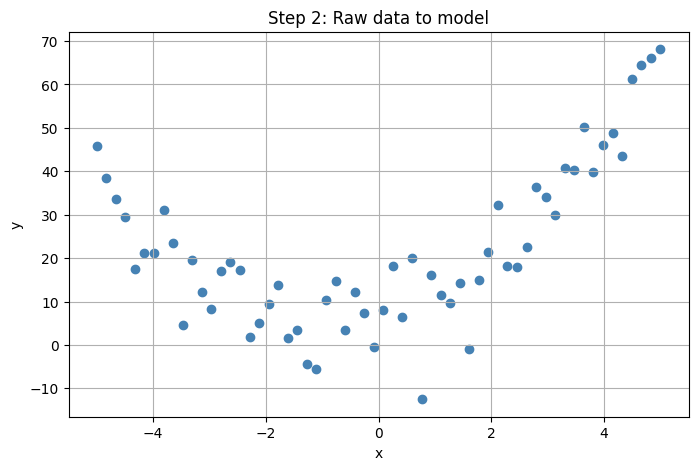

In [91]:
# 1. Data generation — reuse the quadratic dataset from Section 3
X = X_nl.copy()
y = y_nl.copy()

# 2. Data visualization
plt.scatter(X, y, color="steelblue")
plt.title("Step 2: Raw data to model")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

In [92]:
# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 48 | Test size: 12


In [93]:
# 4. Polynomial feature transformation (degree = 2)
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("Original shape:", X_train.shape)
print("Transformed shape:", X_train_poly.shape)
print("Feature names:", poly.get_feature_names_out(["x"]))

Original shape: (48, 1)
Transformed shape: (48, 3)
Feature names: ['1' 'x' 'x^2']


In [94]:
X_train

array([[ 0.25423729],
       [-4.49152542],
       [ 3.81355932],
       [-2.11864407],
       [-3.6440678 ],
       [-3.98305085],
       [ 1.77966102],
       [-4.3220339 ],
       [ 2.28813559],
       [-1.77966102],
       [ 0.76271186],
       [ 4.83050847],
       [-0.76271186],
       [ 4.49152542],
       [-2.45762712],
       [-0.42372881],
       [-3.47457627],
       [ 0.08474576],
       [-0.59322034],
       [-2.28813559],
       [-0.93220339],
       [ 4.3220339 ],
       [-3.13559322],
       [ 0.42372881],
       [ 3.98305085],
       [ 1.94915254],
       [ 1.27118644],
       [-0.08474576],
       [ 2.45762712],
       [-4.83050847],
       [-1.44067797],
       [-4.66101695],
       [ 2.96610169],
       [ 1.61016949],
       [ 0.93220339],
       [-1.10169492],
       [ 3.30508475],
       [-3.30508475],
       [-1.27118644],
       [-1.94915254],
       [ 5.        ],
       [-1.61016949],
       [-3.81355932],
       [ 2.11864407],
       [-2.62711864],
       [-0

In [95]:
X_train_poly

array([[ 1.00000000e+00,  2.54237288e-01,  6.46365987e-02],
       [ 1.00000000e+00, -4.49152542e+00,  2.01738006e+01],
       [ 1.00000000e+00,  3.81355932e+00,  1.45432347e+01],
       [ 1.00000000e+00, -2.11864407e+00,  4.48865269e+00],
       [ 1.00000000e+00, -3.64406780e+00,  1.32792301e+01],
       [ 1.00000000e+00, -3.98305085e+00,  1.58646941e+01],
       [ 1.00000000e+00,  1.77966102e+00,  3.16719334e+00],
       [ 1.00000000e+00, -4.32203390e+00,  1.86799770e+01],
       [ 1.00000000e+00,  2.28813559e+00,  5.23556449e+00],
       [ 1.00000000e+00, -1.77966102e+00,  3.16719334e+00],
       [ 1.00000000e+00,  7.62711864e-01,  5.81729388e-01],
       [ 1.00000000e+00,  4.83050847e+00,  2.33338121e+01],
       [ 1.00000000e+00, -7.62711864e-01,  5.81729388e-01],
       [ 1.00000000e+00,  4.49152542e+00,  2.01738006e+01],
       [ 1.00000000e+00, -2.45762712e+00,  6.03993105e+00],
       [ 1.00000000e+00, -4.23728814e-01,  1.79546107e-01],
       [ 1.00000000e+00, -3.47457627e+00

In [96]:
# 5. Model training
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# 6. Prediction
y_test_pred = poly_model.predict(X_test_poly)

print("Learned coefficients (for [1, x, x^2]):", poly_model.coef_)
print("Intercept:", poly_model.intercept_)

Learned coefficients (for [1, x, x^2]): [0.         2.97509891 1.89741719]
Intercept: 5.294441591942343


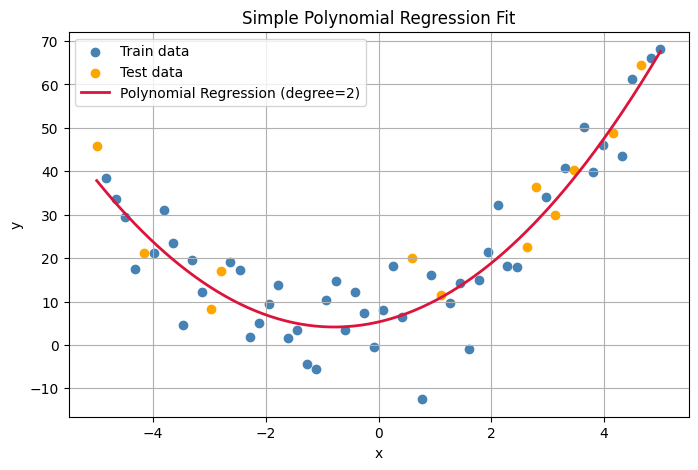

In [97]:
# 7. Visualization — smooth curve across the full x range
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_pred = poly_model.predict(X_range_poly)

plt.scatter(X_train, y_train, label="Train data", color="steelblue")
plt.scatter(X_test, y_test, label="Test data", color="orange")
plt.plot(X_range, y_range_pred, label="Polynomial Regression (degree=2)", color="crimson", linewidth=2)
plt.title("Simple Polynomial Regression Fit")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

In [98]:
# 8. Evaluation
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 4.822
MSE  : 33.077
RMSE : 5.751
R²   : 0.874


Notice how much better this fits compared to the plain straight line in Section 3 — both visually and in the $R^2$ score.

## 7️⃣ What Does `PolynomialFeatures` Actually Do?

Let's look under the hood with a tiny, easy-to-read example.

In [114]:
X_demo = np.array([[2], [3], [4]])

poly_demo2 = PolynomialFeatures(degree=2)
X_demo_poly2 = poly_demo2.fit_transform(X_demo)

print("Original X:\n", X_demo)
# print("\nTransformed (degree=2), columns =", poly_demo2.get_feature_names_out(["x"]))
print(X_demo_poly2)

Original X:
 [[2]
 [3]
 [4]]
[[ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]]


For each row, `PolynomialFeatures(degree=2)` produces:

$$[\,1,\; x,\; x^2\,]$$

- The first column is always `1` — the **bias/intercept** term.
- The second column is the original feature `x`.
- The third column is `x²`.

Let's do the same for **degree 3**.

In [100]:
poly_demo3 = PolynomialFeatures(degree=3)
X_demo_poly3 = poly_demo3.fit_transform(X_demo)

print("Transformed (degree=3), columns =", poly_demo3.get_feature_names_out(["x"]))
print(X_demo_poly3)

Transformed (degree=3), columns = ['1' 'x' 'x^2' 'x^3']
[[ 1.  2.  4.  8.]
 [ 1.  3.  9. 27.]
 [ 1.  4. 16. 64.]]


Now the transformation produces $[\,1,\; x,\; x^2,\; x^3\,]$ — one extra column per extra degree.

## 8️⃣ Multiple Polynomial Regression

Polynomial Regression isn't limited to a single input variable — it works with **multiple independent variables** too.

Example: predicting salary from

- $x_1$ = Experience (years)
- $x_2$ = Age (years)

For `degree=2`, `PolynomialFeatures` generates:

$$x_1,\; x_2,\; x_1^2,\; x_1x_2,\; x_2^2$$

The term $x_1x_2$ is called an **interaction feature** — it captures how the *combined* effect of experience and age influences the target, beyond what each variable explains on its own.

In [101]:
# Synthetic 2-feature dataset: Experience & Age -> Salary
n = 100
experience = np.random.uniform(0, 20, n)
age = np.random.uniform(22, 60, n)

salary = (30000
          + 2500 * experience
          + 150 * age
          + 80 * experience**2
          + 40 * experience * age
          + np.random.normal(0, 4000, n))

X_multi = np.column_stack([experience, age])
y_multi = salary

poly_multi = PolynomialFeatures(degree=2)
X_multi_poly = poly_multi.fit_transform(X_multi)

print("Original features shape:", X_multi.shape)
print("Polynomial features shape:", X_multi_poly.shape)
print("Feature names:", poly_multi.get_feature_names_out(["experience", "age"]))

Original features shape: (100, 2)
Polynomial features shape: (100, 6)
Feature names: ['1' 'experience' 'age' 'experience^2' 'experience age' 'age^2']


In [102]:
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi_poly, y_multi, test_size=0.2, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_multi_train, y_multi_train)
y_multi_pred = multi_model.predict(X_multi_test)

print(f"Test R²: {r2_score(y_multi_test, y_multi_pred):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_multi_test, y_multi_pred)):.2f}")

Test R²: 0.990
Test RMSE: 3221.04


## 9️⃣ Polynomial Degree Experiment — Underfitting vs. Overfitting

This is one of the most important practical lessons in this notebook.

- **Too low a degree** → the model is too simple to capture the curve → **underfitting** (high error on both train and test data).
- **Too high a degree** → the model starts fitting the *noise* in the training data instead of the true trend → **overfitting** (very low train error, but high test error).

Let's compare several degrees side by side on the same dataset.

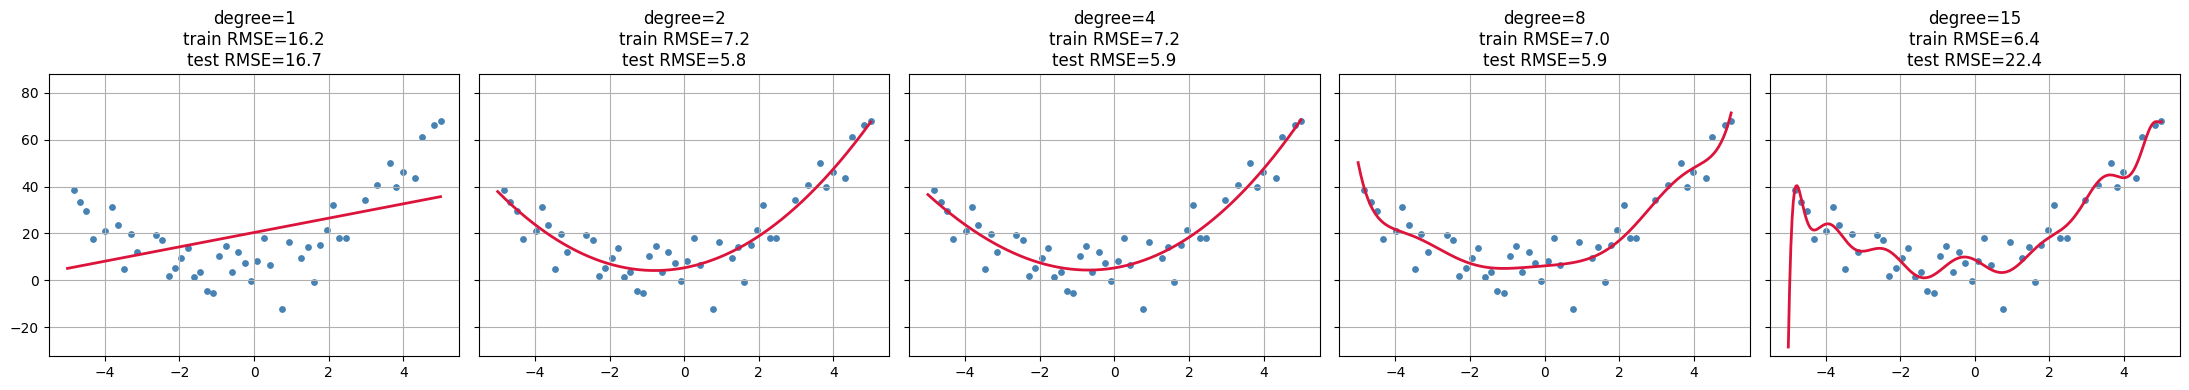

,degree,train_RMSE,test_RMSE
0,1,16.194990,16.743315
1,2,7.191945,5.751270
2,4,7.178910,5.935739
3,8,6.960275,5.866158
4,15,6.436804,22.444128


In [103]:
degrees = [1, 2, 4, 8, 15]

fig, axes = plt.subplots(1, len(degrees), figsize=(22, 4), sharey=True)
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

results = []
for ax, d in zip(axes, degrees):
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    model.fit(X_train, y_train)

    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_tr_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_te_pred))
    results.append((d, train_rmse, test_rmse))

    ax.scatter(X_train, y_train, s=15, color="steelblue")
    ax.plot(X_plot, model.predict(X_plot), color="crimson", linewidth=2)
    ax.set_title(f"degree={d}\ntrain RMSE={train_rmse:.1f}\ntest RMSE={test_rmse:.1f}")
    ax.set_ylim(y.min() - 20, y.max() + 20)

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results, columns=["degree", "train_RMSE", "test_RMSE"])
results_df

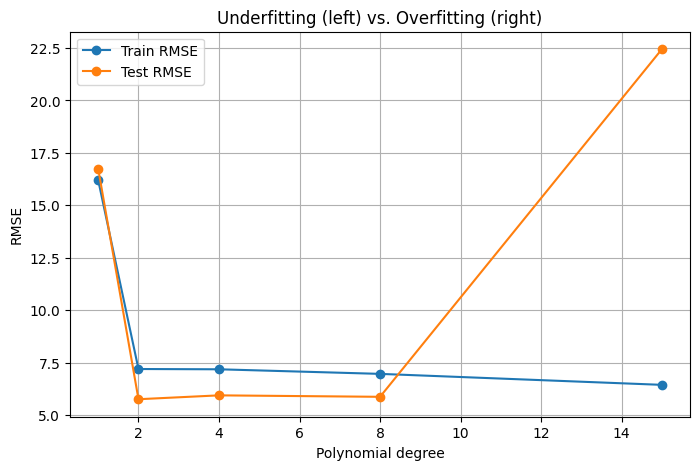

In [104]:
plt.plot(results_df["degree"], results_df["train_RMSE"], marker="o", label="Train RMSE")
plt.plot(results_df["degree"], results_df["test_RMSE"], marker="o", label="Test RMSE")
plt.xlabel("Polynomial degree")
plt.ylabel("RMSE")
plt.title("Underfitting (left) vs. Overfitting (right)")
plt.legend()
plt.show()

**How to read this plot:**

- At low degrees (e.g. `degree=1`), both train and test RMSE are high → **underfitting**.
- Around `degree=2` (the true underlying relationship), both errors are low and close together → a **good fit**.
- At high degrees (e.g. `degree=15`), train RMSE keeps dropping but test RMSE shoots back up → **overfitting** — the model has memorized noise instead of learning the pattern.

The best degree is the one that minimizes **test** error, not train error.

## 🔟 Evaluation Metrics — MAE, MSE, RMSE, R²

| Metric | Formula | Intuition |
|---|---|---|
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum \lvert y_i - \hat{y}_i \rvert$ | Average absolute mistake, in the same units as $y$ |
| **MSE** (Mean Squared Error) | $\frac{1}{n}\sum (y_i - \hat{y}_i)^2$ | Like MAE but penalizes large errors more heavily |
| **RMSE** (Root MSE) | $\sqrt{MSE}$ | MSE brought back to the original units of $y$ |
| **R² (Coefficient of Determination)** | $1 - \frac{\sum (y_i-\hat{y}_i)^2}{\sum (y_i-\bar{y})^2}$ | Fraction of variance in $y$ explained by the model (closer to 1 is better) |

Let's compute all four metrics for the best-performing degree found above (`degree=2`).

In [105]:
best_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
best_model.fit(X_train, y_train)
y_best_pred = best_model.predict(X_test)

print(f"MAE  : {mean_absolute_error(y_test, y_best_pred):.3f}")
print(f"MSE  : {mean_squared_error(y_test, y_best_pred):.3f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_best_pred)):.3f}")
print(f"R²   : {r2_score(y_test, y_best_pred):.3f}")

MAE  : 4.822
MSE  : 33.077
RMSE : 5.751
R²   : 0.874


## 1️⃣1️⃣ Why Feature Scaling Matters for High-Degree Polynomials

When we raise $x$ to higher powers, the scale of the features explodes. For example, if $x$ ranges up to 100:

- $x^1$ → up to 100
- $x^2$ → up to 10,000
- $x^3$ → up to 1,000,000

This huge difference in scale between features can make the underlying optimization **numerically unstable** and can make coefficients hard to interpret. `StandardScaler` fixes this by rescaling every feature to have mean 0 and standard deviation 1.

The fix is simple: build a pipeline of `PolynomialFeatures → StandardScaler → LinearRegression`.

In [106]:
# Compare coefficient magnitudes with and without scaling, at a high degree
high_degree = 10

unscaled_pipe = make_pipeline(PolynomialFeatures(degree=high_degree), LinearRegression())
unscaled_pipe.fit(X_train, y_train)
unscaled_coefs = unscaled_pipe.named_steps["linearregression"].coef_

scaled_pipe = make_pipeline(
    PolynomialFeatures(degree=high_degree),
    StandardScaler(),
    LinearRegression()
)
scaled_pipe.fit(X_train, y_train)
scaled_coefs = scaled_pipe.named_steps["linearregression"].coef_

print("Max |coefficient| WITHOUT scaling:", np.max(np.abs(unscaled_coefs)))
print("Max |coefficient| WITH scaling   :", np.max(np.abs(scaled_coefs)))

Max |coefficient| WITHOUT scaling: 2.903588768996367
Max |coefficient| WITH scaling   : 662.2472045173095


Notice how much larger (and more unstable) the unscaled coefficients are. As a rule of thumb: **whenever you use `degree > 2 or 3`, add a `StandardScaler` step to your pipeline.**

## 1️⃣2️⃣ End-to-End Mini Project

Let's put everything together into one complete, realistic workflow:

1. Load/generate data
2. Train/test split
3. Build a pipeline: `PolynomialFeatures → StandardScaler → LinearRegression`
4. Use `GridSearchCV` to automatically find the best degree
5. Evaluate the final model
6. Visualize the final fit

In [107]:
# 1 & 2. Data (reuse the quadratic dataset) + split already done: X_train, X_test, y_train, y_test

# 3. Pipeline
project_pipe = make_pipeline(
    PolynomialFeatures(include_bias=False),
    StandardScaler(),
    LinearRegression()
)

# 4. Grid search over candidate degrees
param_grid = {"polynomialfeatures__degree": [1, 2, 3, 4, 5, 6, 8, 10]}
grid_search = GridSearchCV(
    project_pipe, param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)
grid_search.fit(X_train, y_train)

print("Best degree found:", grid_search.best_params_["polynomialfeatures__degree"])
print("Best CV RMSE:", -grid_search.best_score_)

Best degree found: 2
Best CV RMSE: 7.531501537708664


In [108]:
# 5. Evaluate the final, best model on the held-out test set
final_model = grid_search.best_estimator_
y_final_pred = final_model.predict(X_test)

print(f"Final Test MAE  : {mean_absolute_error(y_test, y_final_pred):.3f}")
print(f"Final Test RMSE : {np.sqrt(mean_squared_error(y_test, y_final_pred)):.3f}")
print(f"Final Test R²   : {r2_score(y_test, y_final_pred):.3f}")

Final Test MAE  : 4.822
Final Test RMSE : 5.751
Final Test R²   : 0.874


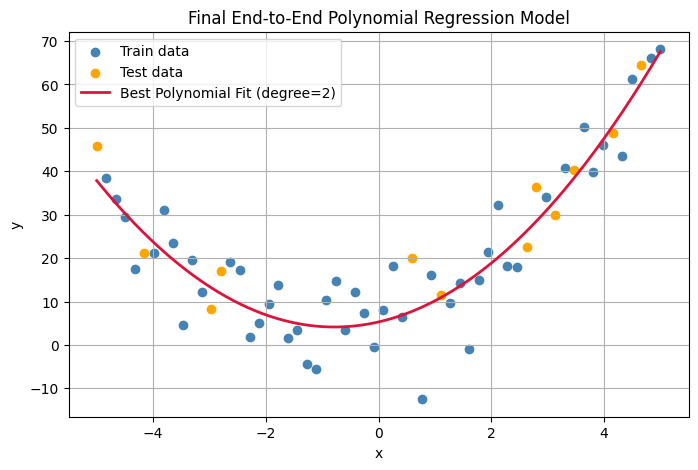

In [109]:
# 6. Visualize the final fitted curve
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_plot_pred = final_model.predict(X_plot)

plt.scatter(X_train, y_train, label="Train data", color="steelblue")
plt.scatter(X_test, y_test, label="Test data", color="orange")
plt.plot(X_plot, y_plot_pred, label=f"Best Polynomial Fit (degree={grid_search.best_params_['polynomialfeatures__degree']})",
         color="crimson", linewidth=2)
plt.title("Final End-to-End Polynomial Regression Model")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

## ✅ Summary

- **Linear Regression** fits a straight line and fails on curved relationships.
- **Polynomial Regression** fits a curve by adding powers of $x$ ($x^2, x^3, \ldots$) as new features.
- Polynomial Regression is still **linear in its parameters**, so it's implemented as `PolynomialFeatures + LinearRegression`.
- The **degree** controls model complexity: too low → underfitting; too high → overfitting.
- Always evaluate on a **held-out test set** using MAE, MSE, RMSE, and $R^2$ — not just training performance.
- For higher-degree polynomials, add **feature scaling** (`StandardScaler`) to keep the optimization numerically stable.
- `GridSearchCV` can automate the search for the best degree using cross-validation.

---
### 🧪 Practice Exercises for Students

1. Replace the synthetic dataset with a real dataset (e.g. `Position_Salaries.csv`) and repeat Sections 6–9.
2. Try `degree=2` on the *linear* dataset from Section 2 — what happens to the extra coefficients?
3. Extend the Multiple Polynomial Regression example (Section 8) to three input features.
4. Plot the learning curve (train/test error vs. training set size) for `degree=2` and `degree=10`.

*Prepared for the 6-Month Joint Certification Programme in AI & ML — NIELIT Ropar × IIT Ropar.*